---

# Modelling R&D

By: Tomás Urdiales

-> Notebook for modelling experiments.

##### Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error

from src import utils
from src.cross_validation import backtesting_CV
from src.join_qh_min_data import join_qh_min_data

##### Parameters

In [2]:
CWD = utils.get_root_dir()

# To not use darts plotting style:
plt.style.use('default')

DPI = 150 # (pixel density for figures)
ELIA_ORANGE = (250/256, 115/256, 1/256) # RGB

##### Load data

In [3]:
qh = utils.load_qh_historical_data().loc["2021":"2022"]
minute = utils.load_min_historical_data().loc["2021":"2022"]
ems = utils.load_ems_historical_data().loc["2021":"2022"]
xb = utils.load_xb_historical_data().loc["2021":"2022"]

# Additional features:
ems.insert(1, "elia_sum_prod_mw_cm-value-diff", ems["elia_sum_prod_mw_cm-value"].diff())
minute["rolling_15"] = minute["system_imbalance"].rolling(window=15, center=False).mean()
minute["rolling_60"] = minute["system_imbalance"].rolling(window=60, center=False).mean()

# Add in XB data:
qh = qh.assign(xb_day_ahead = xb["xb_day_ahead"])
qh = qh.assign(xb_intraday = xb["xb_intraday"])
qh = qh.assign(xb_grand_total = xb["xb_grand_total"])
qh = qh.assign(xb_physical_accounting_net_import_mw = xb["xb_physical_accounting_net_import_mw"])

In [4]:
def check(a,b):
    print(f"{(1-a/109.79)*100 :.2f}% | {(1-b/146.02)*100 :.2f}%")

---

## Legacy model benchmark

In [117]:
MINUTE = "all"

qh_parameters = {
    "system_imbalance_cum15": {
        "lags": [1]},
    "si_mw": {
        "lags": [-1, -2, -3, -4]},
    "load_id_mw": {
        "lags": [3, 2, 1, 0, -1, -2, -3, -4]},
    "nrv_rt": {
        "lags": [-1, -2, -3, -4]},
}

minute_parameters = {
    "system_imbalance": {
        "lags": [0, -1, -2, -3]},
    "net_regulation_volume": {
        "lags": [0, -1, -2, -3]},
}

# Prepare training dataframe:d
df = join_qh_min_data(
    qh_data=qh,
    minute_data=minute,
    qh_parameters=qh_parameters,
    minute_parameters=minute_parameters,
    minute=MINUTE,
)
TARGET = "system_imbalance_cum15_from_qh_plus_1"
FEATURES = [feature for feature in df.columns if feature != TARGET]

df = df.dropna()

# Set up splits and model features:
tscv = TimeSeriesSplit(n_splits=52 * 7 // 4, max_train_size=15 * 4 * 24 * 7 * 8, test_size=15 * 4 * 24 * 4, gap=0)

# Cross-validation:
results_linear = backtesting_CV(model=LinearRegression(),
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                target=TARGET,
                                progress_bar=True,
                                verbose=False
                                )

MODEL: LinearRegression
Time configuration: 91 splits, 4 testing days, 8 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [00:20<00:00,  4.39it/s]



Train set average error:
MAE: 108.48MW | RMSE: 144.25MW
Test set average error:
MAE: 109.79MW | RMSE: 146.02MW | MASE: 0.7324 | P90 Error: 232.26MW | Max Error: 1107.1 (2022-09-06 21:15:00+02:00)
Time elapsed: 20.82s | Time per split: ~0.23s



---

## Naive estimator

In [6]:
TARGET = "system_imbalance_cum15_from_qh_plus_1"

lag = 2
if MINUTE == "all":
    lag = 15 * lag

total_mae = mean_absolute_error(df[TARGET].loc["2022"][lag:], df[TARGET].loc["2022"].shift(lag)[lag:])
total_rmse = mean_squared_error(df[TARGET].loc["2022"][lag:], df[TARGET].loc["2022"].shift(lag)[lag:], squared=False)
print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")

check(149.88, 195.53)

Total MAE: 149.88MW | Total RMSE: 195.53MW
-36.52% | -33.91%


---

## CV: all 15 minutes

In [185]:
MINUTE = "all"

qh_parameters = {
    "system_imbalance_cum15": {
        "lags": [1, -1, -2, -3, -5, -95, -94, -93, -96, -671, -670, -669]},

    "total_load_last_mw": {
        "lags": [3, 2, 1, 0, -1, -2, -3, -4]},

    "nrv_rt": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "load_rt_mw": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "wind_rt_mw": {
        "lags": [-1, -2, -3, -4]},
}

minute_parameters = {
    "system_imbalance": {
        "lags": [0, -1, -4]},

    "net_regulation_volume": {
        "lags": [0, -1, -2, -3, -4]},
    "rolling_15": {
        "lags": [0]},
    "rolling_60": {
        "lags": [0]},
}

# Prepare training dataframe:
df = join_qh_min_data(
    qh_data=qh,
    minute_data=minute,
    qh_parameters=qh_parameters,
    minute_parameters=minute_parameters,
    minute=MINUTE,
    # ems_data=ems,
    # ems_parameters=ems_parameters,
)
TARGET = "system_imbalance_cum15_from_qh_plus_1"
FEATURES = [feature for feature in df.columns if feature != TARGET]

df = df.dropna()

# Set up splits and model features:
tscv = TimeSeriesSplit(
    n_splits=52 * 7 // 4,
    max_train_size=15 * 4 * 24 * 7 * 20,
    test_size=15 * 4 * 24 * 4,
    gap=0
)

In [186]:
# Cross-validation:
results_linear = backtesting_CV(model=LinearRegression(n_jobs=-1),
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                target=TARGET,
                                progress_bar=True,
                                use_scaler=True,
                                verbose=False)

check(106.42, 141.96)

MODEL: LinearRegression
Time configuration: 91 splits, 4 testing days, 20 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [01:09<00:00,  1.32it/s]



Train set average error:
MAE: 103.36MW | RMSE: 137.95MW
Test set average error:
MAE: 106.42MW | RMSE: 141.96MW | MASE: 0.7099 | P90 Error: 225.19MW | Max Error: 1104.3 (2022-10-05 10:00:00+02:00)
Time elapsed: 69.27s | Time per split: ~0.76s

3.07% | 2.78%


In [9]:
# If we look at results for individual minutes, 
# we find equivalent or slightly worse performance to single-min models:
results = results_linear[0].loc[results_linear[0].index.minute % 15 == 10].loc["2022"]

total_mae = mean_absolute_error(results["y_test"], results["y_pred"])
total_rmse = mean_squared_error(results["y_test"], results["y_pred"], squared=False)
print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")
check(103.81, 138.59)

Total MAE: 103.67MW | Total RMSE: 138.48MW
5.45% | 5.09%


---

## CV (XB set): all 15 minutes

In [13]:
MINUTE = "all"

qh_parameters = {
    "system_imbalance_cum15": {
        "lags": [1, -1, -2, -3, -4, -5, -95, -94, -93, -96, -671, -670, -669]},

    "xb_day_ahead": {
        "lags": [5, 1, 0, -4]},
    "xb_intraday": {
        "lags": [5, 1, 0, -4]},
    "xb_grand_total": {
        "lags": [5, 1, 0, -4]},
    "xb_physical_accounting_net_import_mw": {
        "lags": [-1, -2, -3, -4]},

    "total_load_last_mw": {
        "lags": [3, 2, 1, 0, -1, -2, -3, -4]},

    "nrv_rt": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "load_rt_mw": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "wind_rt_mw": {
        "lags": [-1, -2, -3, -4]},
}

minute_parameters = {
    "system_imbalance": {
        "lags": [0, -1, -4]},

    "net_regulation_volume": {
        "lags": [0, -1, -2, -3, -4]},
    "rolling_15": {
        "lags": [0]},
    "rolling_60": {
        "lags": [0]},
}

# Prepare training dataframe:
df = join_qh_min_data(
    qh_data=qh,
    minute_data=minute,
    qh_parameters=qh_parameters,
    minute_parameters=minute_parameters,
    minute=MINUTE,
    # ems_data=ems,
    # ems_parameters=ems_parameters,
)
TARGET = "system_imbalance_cum15_from_qh_plus_1"
FEATURES = [feature for feature in df.columns if feature != TARGET]

df = df.dropna()

# Set up splits and model features:
tscv = TimeSeriesSplit(
    n_splits=52 * 7 // 4,
    max_train_size=15 * 4 * 24 * 7 * 20,
    test_size=15 * 4 * 24 * 4,
    gap=0
)

In [14]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(
    alpha=0.5,
    tol=1e-4,
    max_iter=1000,
    solver="auto",
)

# Cross-validation:
results_linear = backtesting_CV(model=model_ridge,
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                target=TARGET,
                                progress_bar=True,
                                use_scaler=True,
                                verbose=False)
check(102.95, 136.15)

MODEL: Ridge
Time configuration: 91 splits, 60 testing days, 300 training weeks. Total predicted time: 5460 days.



100%|██████████| 91/91 [00:31<00:00,  2.87it/s]


Train set average error:
MAE: 99.88MW | RMSE: 132.03MW
Test set average error:
MAE: 102.95MW | RMSE: 136.15MW | MASE: 6.5811 | P90 Error: 217.26MW | Max Error: 1129.8 (2022-10-05 10:00:00+02:00)
Time elapsed: 31.94s | Time per split: ~0.35s

6.23% | 6.76%


In [11]:
from sklearn.linear_model import Ridge

model_ridge = Ridge(
    alpha=0.5,
    tol=1e-4,
    max_iter=1000,
    solver="auto",
)

# Cross-validation:
results_linear = backtesting_CV(model=model_ridge,
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                target=TARGET,
                                progress_bar=True,
                                use_scaler=True,
                                verbose=False)
check(102.95, 136.15)

MODEL: Ridge
Time configuration: 91 splits, 4 testing days, 20 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [00:28<00:00,  3.20it/s]


Train set average error:
MAE: 103.32MW | RMSE: 137.90MW
Test set average error:
MAE: 106.39MW | RMSE: 141.93MW | MASE: 0.7097 | P90 Error: 225.29MW | Max Error: 1105.2 (2022-10-05 10:00:00+02:00)
Time elapsed: 28.61s | Time per split: ~0.31s

6.23% | 6.76%


In [9]:
results_linear = backtesting_CV(model=LinearRegression(n_jobs=-1),
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                target=TARGET,
                                progress_bar=True,
                                use_scaler=True,
                                verbose=False)
check(102.99, 136.20) # !!!

MODEL: LinearRegression
Time configuration: 91 splits, 4 testing days, 20 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [01:02<00:00,  1.46it/s]


Train set average error:
MAE: 100.02MW | RMSE: 132.26MW
Test set average error:
MAE: 102.95MW | RMSE: 136.17MW | MASE: 0.6868 | P90 Error: 217.56MW | Max Error: 1132.5 (2022-10-05 10:00:00+02:00)
Time elapsed: 62.41s | Time per split: ~0.69s

6.19% | 6.73%


In [12]:
selected_features_Lasso = ['system_imbalance_cum15_from_qh_minus_2',
       'system_imbalance_cum15_from_qh_minus_3',
       'system_imbalance_cum15_from_qh_minus_4',
       'system_imbalance_cum15_from_qh_minus_5',
       'system_imbalance_cum15_from_qh_minus_95',
       'system_imbalance_cum15_from_qh_minus_94',
       'system_imbalance_cum15_from_qh_minus_93',
       'system_imbalance_cum15_from_qh_minus_96',
       'system_imbalance_cum15_from_qh_minus_671',
       'system_imbalance_cum15_from_qh_minus_670',
       'system_imbalance_cum15_from_qh_minus_669',
       'xb_day_ahead_from_qh_minus_4', 'xb_intraday_from_qh_plus_5',
       'xb_intraday_from_qh_plus_1', 'xb_intraday_current_qh',
       'xb_grand_total_from_qh_plus_5', 'xb_grand_total_from_qh_plus_1',
       'xb_grand_total_current_qh',
       'xb_physical_accounting_net_import_mw_from_qh_minus_1',
       'xb_physical_accounting_net_import_mw_from_qh_minus_3',
       'total_load_last_mw_from_qh_plus_3',
       'total_load_last_mw_from_qh_minus_3', 'nrv_rt_from_qh_minus_1',
       'nrv_rt_from_qh_minus_2', 'nrv_rt_from_qh_minus_3',
       'nrv_rt_from_qh_minus_95', 'nrv_rt_from_qh_minus_671',
       'load_rt_mw_from_qh_minus_671', 'wind_rt_mw_from_qh_minus_1',
       'system_imbalance_current_minute',
       'net_regulation_volume_current_minute',
       'net_regulation_volume_from_minute_minus_4',
       'rolling_15_current_minute']

# Cross-validation:
results_linear = backtesting_CV(model=LinearRegression(n_jobs=-1),
                                data=df,
                                time_splits=tscv,
                                features=selected_features_Lasso,
                                target=TARGET,
                                progress_bar=True,
                                use_scaler=True,
                                verbose=False)

check(103.48, 136.68)


MODEL: LinearRegression
Time configuration: 91 splits, 4 testing days, 20 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [00:41<00:00,  2.20it/s]



Train set average error:
MAE: 100.81MW | RMSE: 133.05MW
Test set average error:
MAE: 103.48MW | RMSE: 136.68MW | MASE: 0.6904 | P90 Error: 218.63MW | Max Error: 1152.3 (2022-10-05 10:00:00+02:00)
Time elapsed: 41.52s | Time per split: ~0.46s

5.75% | 6.40%


In [158]:
from sklearn.neural_network import MLPRegressor

tscv = TimeSeriesSplit(
    n_splits=52 // 2 // 2, max_train_size=15 * 4 * 24 * 7 * 50, test_size=15 * 4 * 24 * 7 * 2 * 2, gap=0
)

model_mlp = MLPRegressor(
    hidden_layer_sizes=[10, 10],
    alpha=0.1,
    tol=1e-2,
    shuffle=True,
    activation="relu",
    solver="lbfgs",
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=5,
    momentum=True,
    verbose=False,
)

# Cross-validation:
results_mlp = backtesting_CV(
    model=model_mlp,
    data=df,
    time_splits=tscv,
    use_scaler=True,
    features=FEATURES,
    target=TARGET,
    progress_bar=True,
    verbose=False,
)

check(101.39, 135.63)

MODEL: MLPRegressor
Time configuration: 13 splits, 28 testing days, 50 training weeks. Total predicted time: 364 days.



  0%|          | 0/13 [00:00<?, ?it/s]/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
  8%|▊         | 1/13 [02:37<31:31, 157.63s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
 15%|█▌        | 2/13 [05:10<28:23, 154.82s/it]/opt/homebrew/lib/python3.11/site-packages/s


Train set average error:
MAE: 90.57MW | RMSE: 120.25MW
Test set average error:
MAE: 101.39MW | RMSE: 135.63MW | MASE: 0.6764 | P90 Error: 212.96MW | Max Error: 2128.8 (2022-10-31 12:45:00+01:00)
Time elapsed: 1850.69s | Time per split: ~142.36s



In [6]:
# Let's encode the minute of qh with dummy variables:
df = df.assign(minute_of_qh=(df.index.minute % 15).astype("category"))
df = pd.get_dummies(df,
    columns=["minute_of_qh"],
    drop_first=True,
    prefix="min", prefix_sep="_")

In [8]:
from sklearn.neural_network import MLPRegressor

tscv = TimeSeriesSplit(
    n_splits=52 // 2 // 2, max_train_size=15 * 4 * 24 * 7 * 70, test_size=15 * 4 * 24 * 7 * 4, gap=0
)

model_mlp = MLPRegressor(
    hidden_layer_sizes=[12, 12],
    alpha=0.15,
    tol=1e-3,
    shuffle=True,
    activation="relu",
    solver="lbfgs",
    max_iter=400,
    early_stopping=True,
    n_iter_no_change=5,
    momentum=True,
    verbose=False,
)

# Cross-validation:
results_mlp = backtesting_CV(
    model=model_mlp,
    data=df,
    time_splits=tscv,
    use_scaler=True,
    features=FEATURES,
    target=TARGET,
    progress_bar=True,
    verbose=False,
)

check(100.75, 133.45)

MODEL: MLPRegressor
Time configuration: 13 splits, 28 testing days, 70 training weeks. Total predicted time: 364 days.



  0%|          | 0/13 [00:00<?, ?it/s]

/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
  8%|▊         | 1/13 [02:03<24:38, 123.20s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
 15%|█▌        | 2/13 [04:13<23:23, 127.61s/it]/opt/homebrew/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perc


Train set average error:
MAE: 89.23MW | RMSE: 118.88MW
Test set average error:
MAE: 100.75MW | RMSE: 133.45MW | MASE: 0.6722 | P90 Error: 212.89MW | Max Error: 1197.1 (2022-10-05 10:00:00+02:00)
Time elapsed: 2025.59s | Time per split: ~155.81s

7.92% | 8.34%


---

## qh-minute errors

In [10]:
def show_error_per_minute(df):
    df = df.copy().assign(minute_of_qh=(df.index.minute % 15).astype("category"))
    metrics_per_minute = np.array([]).reshape(0,3)

    for minute in (df.index.minute % 15).unique():
        df_minute = df.loc[df["minute_of_qh"] == minute]
        total_mae = mean_absolute_error(df_minute["y_pred"], df_minute["y_test"])
        total_rmse = mean_squared_error(df_minute["y_pred"], df_minute["y_test"], squared=False)

        metrics_per_minute = np.vstack([metrics_per_minute, np.array([minute, total_mae, total_rmse])])
    
    # Turn into a dataframe:
    metrics_per_minute = pd.DataFrame(metrics_per_minute, columns=["minute_of_qh", "MAE", "RMSE"]) \
        .set_index("minute_of_qh")
    # And plot:
    metrics_per_minute.plot(kind="bar")
    plt.ylim(0, 160)
    plt.xlabel("Minute of qh"); plt.ylabel("Error [MW]")
    plt.xticks(range(15), labels=[str(ii) for ii in range(15)], rotation=0)
    # plt.grid()
    plt.show()
    # return metrics_per_minute

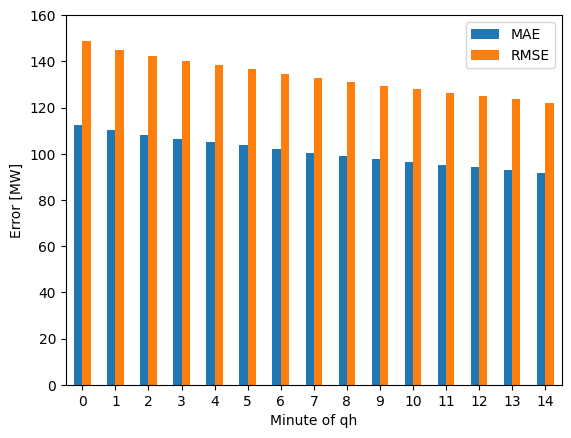

In [11]:
show_error_per_minute(results_mlp[0])

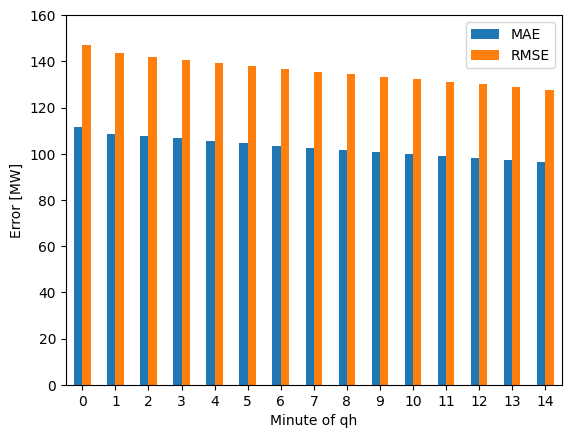

In [46]:
show_error_per_minute(results_linear[0])

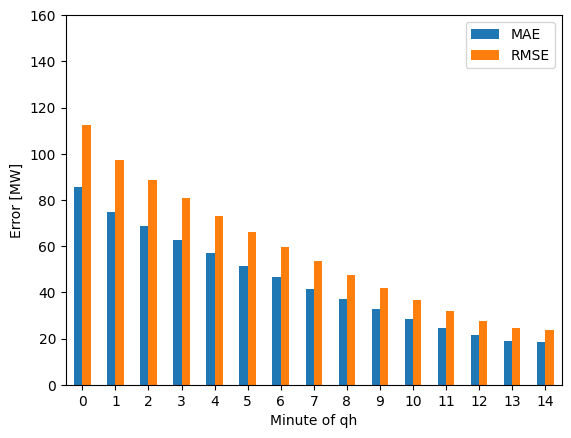

In [49]:
# Checking for qh+0 forecasts:
show_error_per_minute(results_linear[0])

---

## R&D

In [12]:
from sklearn.linear_model import HuberRegressor

tscv = TimeSeriesSplit(
    n_splits=52 // 2, max_train_size=15 * 4 * 24 * 7 * 20, test_size=15 * 4 * 24 * 7 * 2, gap=0
)

model_huber = HuberRegressor(
    epsilon=1.2,
    max_iter=500,
    alpha=0,
    tol=1e-2,
)

# Cross-validation:
results_huber = backtesting_CV(
    model=model_huber,
    data=df,
    time_splits=tscv,
    features=FEATURES,
    target=TARGET,
    use_scaler=True,
    progress_bar=True,
    verbose=False
)

check(102.83, 136.27)

MODEL: HuberRegressor
Time configuration: 26 splits, 14 testing days, 20 training weeks. Total predicted time: 364 days.



100%|██████████| 26/26 [09:08<00:00, 21.11s/it]


Train set average error:
MAE: 99.50MW | RMSE: 132.03MW
Test set average error:
MAE: 102.83MW | RMSE: 136.27MW | MASE: 0.6860 | P90 Error: 217.32MW | Max Error: 1138.9 (2022-10-05 10:00:00+02:00)
Time elapsed: 548.95s | Time per split: ~21.11s

6.18% | 6.03%


In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model_pca = make_pipeline(StandardScaler(), PCA(20), LinearRegression())

# Cross-validation:
results_pca = backtesting_CV(
    model=model_pca,
    data=df,
    time_splits=tscv,
    features=FEATURES,
    target=TARGET,
    use_scaler=False,
    progress_bar=True,
    verbose=False)

In [120]:
from sklearn.svm import SVR

svr = SVR(
    kernel="rbf",
    gamma="scale",
    C=20,
    epsilon=0.1,
    cache_size=1000,  # [MB]
)

# Cross-validation:
results_svr = backtesting_CV(model=svr,
                             data=df,
                             time_splits=tscv,
                             features=FEATURES,
                             use_scaler=True,
                             target=TARGET,
                             progress_bar=True,
                             verbose=False)

In [7]:
from sklearn.svm import LinearSVR

# Set up splits and model features:
tscv = TimeSeriesSplit(
    n_splits=52,
    max_train_size=15 * 4 * 24 * 7 * 20,
    test_size=15 * 4 * 24 * 7,
    gap=0
)

svr = LinearSVR(
    tol=1e-3,
    C=25,
    epsilon=0.1,
    fit_intercept=True,
    max_iter=500,
)

# Cross-validation:
results_svr = backtesting_CV(
    model=svr,
    data=df, 
    time_splits=tscv,
    features=FEATURES,
    use_scaler=True,
    target=TARGET,
    progress_bar=True,
    verbose=False
)

check(102.82, 136.27)

MODEL: LinearSVR
Time configuration: 52 splits, 7 testing days, 20 training weeks. Total predicted time: 364 days.



  0%|          | 0/52 [00:00<?, ?it/s]

100%|██████████| 52/52 [09:22<00:00, 10.82s/it]


Train set average error:
MAE: 99.64MW | RMSE: 132.30MW
Test set average error:
MAE: 102.82MW | RMSE: 136.27MW | MASE: 0.6859 | P90 Error: 217.45MW | Max Error: 1143.2 (2022-10-05 10:00:00+02:00)
Time elapsed: 562.70s | Time per split: ~10.82s

6.28% | 5.95%


In [31]:
from sklearn.linear_model import SGDRegressor

tscv = TimeSeriesSplit(
    n_splits=52, max_train_size=15 * 4 * 24 * 7 * 30, test_size=15 * 4 * 24 * 7, gap=0
)

sgd = SGDRegressor(
    alpha=0,
    tol=1e-3,
    max_iter=1000,
)

# Cross-validation:
results_sgd = backtesting_CV(
    model=sgd,
    data=df,
    time_splits=tscv,
    features=FEATURES,
    use_scaler=True,
    target=TARGET,
    progress_bar=True,
    verbose=False,
)

MODEL: SGDRegressor
Time configuration: 52 splits, 7 testing days, 30 training weeks. Total predicted time: 364 days.



100%|██████████| 52/52 [03:23<00:00,  3.91s/it]


Train set average error:
MAE: 98.97MW | RMSE: 130.84MW
Test set average error:
MAE: 103.11MW | RMSE: 136.42MW | MASE: 0.6879 | P90 Error: 217.84MW | Max Error: 1115.9 (2022-10-05 10:00:00+02:00)
Time elapsed: 203.43s | Time per split: ~3.91s



In [10]:
from sklearn.ensemble import RandomForestRegressor

tscv = TimeSeriesSplit(
    n_splits=52 // 2, max_train_size=15 * 4 * 24 * 7 * 50, test_size=15 * 4 * 24 * 7 * 2, gap=0
)

# Fit a Random Forest regressor model:
forest = RandomForestRegressor(
    n_estimators=150,
    max_depth=6,
    criterion="squared_error",
    n_jobs=-1,
    verbose=False
)

# Cross-validation:
results_forest = backtesting_CV(model=forest,
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                use_scaler=False,
                                target=TARGET,
                                progress_bar=True,
                                verbose=False)

In [191]:
from sklearn.ensemble import HistGradientBoostingRegressor


tscv = TimeSeriesSplit(
    n_splits=52 // 2, max_train_size=15 * 4 * 24 * 7 * 50, test_size=15 * 4 * 24 * 7 * 2, gap=0
)

# Fit a Random Forest regressor model:
forest = HistGradientBoostingRegressor(
    max_iter=500,
    max_leaf_nodes=5,
    l2_regularization=1,
    max_depth=5,
    verbose=False,
)

# Cross-validation:
results_forest = backtesting_CV(
    model=forest,
    data=df,
    time_splits=tscv,
    features=FEATURES,
    use_scaler=False,
    target=TARGET,
    progress_bar=True,
    verbose=False,
)

check(105.17, 139.71)

MODEL: HistGradientBoostingRegressor
Time configuration: 26 splits, 14 testing days, 50 training weeks. Total predicted time: 364 days.



100%|██████████| 26/26 [02:57<00:00,  6.81s/it]


Train set average error:
MAE: 92.84MW | RMSE: 121.80MW
Test set average error:
MAE: 105.17MW | RMSE: 139.71MW | MASE: 0.7016 | P90 Error: 222.89MW | Max Error: 1131.5 (2022-09-06 21:15:00+02:00)
Time elapsed: 177.09s | Time per split: ~6.81s

4.65% | 4.88%


In [ ]:
from xgboost import XGBRFRegressor

tscv = TimeSeriesSplit(
    n_splits=52 // 2, max_train_size=15 * 4 * 24 * 7 * 50, test_size=15 * 4 * 24 * 7 * 2, gap=0
)

# Start with a random forests attempt:
model_xgboost = XGBRFRegressor(
    max_depth=5,
    booster='gbtree',
    n_estimators=150,
    objective='reg:squarederror',
    n_jobs=-1
)

results_forest = backtesting_CV(model=model_xgboost,
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                use_scaler=False,
                                target=TARGET,
                                progress_bar=True,
                                verbose=False)

---

## Ensembles

In [210]:
# Basic arithmetic mean ensemble:
ensemble = (
    # results_linear[0]["y_pred"] + \
    # results_huber[0]["y_pred"] + \
    results_mlp[0]["y_pred"] + \
    # results_forest[0]["y_pred"] + \
    # results_sgd[0]["y_pred"] + \
    results_svr[0]["y_pred"] + \
    results_mlp[0]["y_pred"]\
    )/3
# ensemble = results_mlp[0]["y_pred"]

total_mae = mean_absolute_error(ensemble, results_linear[0]["y_test"])
total_rmse = np.sqrt(mean_squared_error(ensemble, results_linear[0]["y_test"]))
print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")

check(99.93, 132.4)

Total MAE: 99.93MW | Total RMSE: 132.40MW
8.98% | 9.33%


In [211]:
if "ensemble" in locals():
    ensemble = pd.DataFrame(
        data={
            "y_test": results_linear[0]["y_test"],
            "linear": results_linear[0]["y_pred"],
            "mlp": results_mlp[0]["y_pred"],
            "huber": results_huber[0]["y_pred"],
            "svr": results_svr[0]["y_pred"],
            "sgd": results_sgd[0]["y_pred"],
            "forest": results_forest[0]["y_pred"],
        },
        index=results_linear[0].index
    )
    ensemble.to_pickle("ensemble.pkl")
else:
    ensemble = pd.read_pickle("ensemble.pkl")

# results_mlp = results_linear.copy()
# results_mlp[0]["y_pred"] = pd.read_csv("results_mlp.csv")["y_pred"].values.astype(np.float32)
# total_mae = mean_absolute_error(results_mlp[0]["y_pred"], results_linear[0]["y_test"])
# total_rmse = np.sqrt(mean_squared_error(results_mlp[0]["y_pred"], results_linear[0]["y_test"]))
# print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")

Total MAE: 102.95MW | Total RMSE: 136.15MW


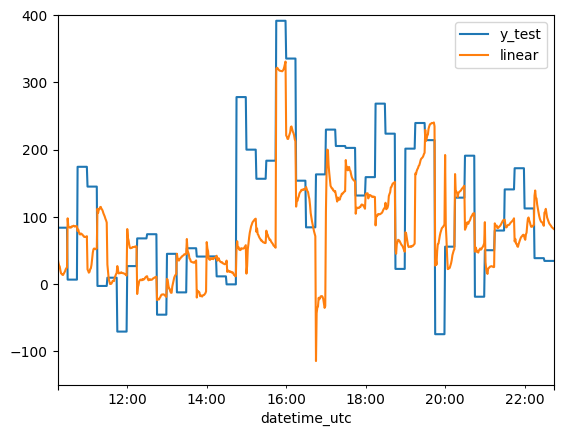

In [212]:
total_mae = mean_absolute_error(ensemble.y_test, ensemble.linear)
total_rmse = mean_squared_error(ensemble.y_test, ensemble.linear, squared=False)
print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")

ensemble[["y_test", "linear"]].tail(15*50).plot();
plt.ylim(-150, 400);

plt.gcf().savefig("linear.png", dpi=300)

# import matplotlib.dates as mdates
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d %H:%M'))
# plt.gcf().autofmt_xdate()

Total MAE: 100.56MW | Total RMSE: 133.15MW


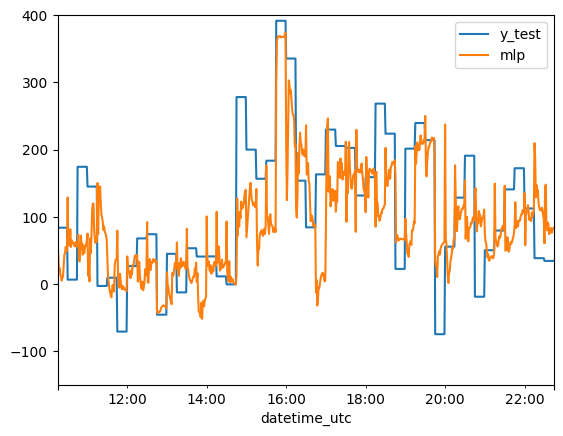

In [213]:
total_mae = mean_absolute_error(ensemble.y_test, ensemble.mlp)
total_rmse = mean_squared_error(ensemble.y_test, ensemble.mlp, squared=False)
print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")

ensemble[["y_test", "mlp"]].tail(15*50).plot();
plt.ylim(-150, 400);

plt.gcf().savefig("mlp.png", dpi=300)

# import matplotlib.dates as mdates
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d %H:%M'))
# plt.gcf().autofmt_xdate()

In [214]:
ensemble = ensemble.dropna()

# Fit en ensemble stacking using 3/4 of data:
fit = LinearRegression().fit(
    ensemble.drop("y_test", axis=1).iloc[:3*len(ensemble)//4, :], 
    ensemble["y_test"].iloc[:3*len(ensemble)//4]
    )
pd.DataFrame(data={"coef":fit.coef_}, index=ensemble.drop("y_test", axis=1).columns)

,coef
linear,-0.071948
mlp,0.668576
huber,-0.175222
svr,0.540140
sgd,-0.058689
forest,0.155915


In [215]:
best = fit.predict(ensemble.drop("y_test", axis=1))

total_mae = mean_absolute_error(best, ensemble["y_test"])
total_rmse = np.sqrt(mean_squared_error(best, ensemble["y_test"]))
print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")

check(99.88, 132.21)

Total MAE: 99.94MW | Total RMSE: 132.27MW
9.03% | 9.46%


In [216]:
# Fit an ensemble stacking using all data:
fit = LinearRegression().fit(
    ensemble.drop("y_test", axis=1),
    ensemble["y_test"]
    )
pd.DataFrame(data={"coef":fit.coef_}, index=ensemble.drop("y_test", axis=1).columns)

,coef
linear,-0.008906
mlp,0.678955
huber,-0.251673
svr,0.526573
sgd,-0.044740
forest,0.138471


In [217]:
best = fit.predict(ensemble.drop("y_test", axis=1))

total_mae = mean_absolute_error(best, ensemble["y_test"])
total_rmse = np.sqrt(mean_squared_error(best, ensemble["y_test"]))
print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")

check(99.86, 132.25)

Total MAE: 99.86MW | Total RMSE: 132.25MW
9.04% | 9.43%


---

## Predicting diff()

In [171]:
MINUTE = "all"
qh_parameters = {
    "system_imbalance_cum15": {
        "lags": [0, -1, -2, -3, -4, -5, -95, -94, -93, -96, -671, -670, -669]},

    "total_load_last_mw": {
        "lags": [-1, -2, -3, -4]},
    "nrv_rt": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "load_rt_mw": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "wind_rt_mw": {
        "lags": [-1, -2, -3, -4]},
}

minute_parameters = {
    "system_imbalance": {
        "lags": [0, -1, -4]},

    "net_regulation_volume": {
        "lags": [0, -1, -2, -3, -4]},
    "rolling_15": {
        "lags": [0]},
    "rolling_60": {
        "lags": [0]},
}

# Prepare training dataframe:
df = join_qh_min_data(
    qh_data=qh,
    minute_data=minute,
    qh_parameters=qh_parameters,
    minute_parameters=minute_parameters,
    minute=MINUTE,
    # ems_data=ems,
    # ems_parameters=ems_parameters,
)
TARGET = "system_imbalance_cum15_current_qh"
FEATURES = [feature for feature in df.columns if feature != TARGET]
# FEATURES.remove("system_imbalance_cum15_from_qh_plus_1")

df = df.dropna()

# Set up splits and model features:
tscv = TimeSeriesSplit(n_splits=52 * 7 // 4, max_train_size=15 * 4 * 24 * 7 * 20, test_size=15 * 4 * 24 * 4, gap=0)

In [172]:
# Cross-validation:
results_linear = backtesting_CV(model=LinearRegression(n_jobs=-1),
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                target=TARGET,
                                progress_bar=True,
                                use_scaler=True,
                                verbose=False)

MODEL: LinearRegression
Time configuration: 91 splits, 4 testing days, 20 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [00:59<00:00,  1.53it/s]


Train set average error:
MAE: 43.62MW | RMSE: 62.41MW
Test set average error:
MAE: 45.06MW | RMSE: 64.21MW | MASE: 0.3840 | P90 Error: 102.52MW | Max Error: 819.7 (2022-10-05 10:00:00+02:00)
Time elapsed: 59.53s | Time per split: ~0.65s



In [173]:
qh["diff_system_imbalance_cum15"] = qh["system_imbalance_cum15"].diff()

MINUTE = "all"
qh_parameters = {
    "system_imbalance_cum15": {
        "lags": [0],
    },
    "diff_system_imbalance_cum15": {
        "lags": [0, -1, -2, -3, -4, -5, -95, -94, -93, -96, -671, -670, -669]},

    "total_load_last_mw": {
        "lags": [-1, -2, -3, -4]},
    "nrv_rt": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "load_rt_mw": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "wind_rt_mw": {
        "lags": [-1, -2, -3, -4]},
}

minute_parameters = {
    "system_imbalance": {
        "lags": [0, -1, -4]},

    "net_regulation_volume": {
        "lags": [0, -1, -2, -3, -4]},
    "rolling_15": {
        "lags": [0]},
    "rolling_60": {
        "lags": [0]},
}

# Prepare training dataframe:
df = join_qh_min_data(
    qh_data=qh,
    minute_data=minute,
    qh_parameters=qh_parameters,
    minute_parameters=minute_parameters,
    minute=MINUTE,
    # ems_data=ems,
    # ems_parameters=ems_parameters,
)
TARGET = "diff_system_imbalance_cum15_current_qh"
FEATURES = [feature for feature in df.columns if feature != TARGET]
FEATURES.remove("system_imbalance_cum15_current_qh")

df = df.dropna()

# Set up splits and model features:
tscv = TimeSeriesSplit(n_splits=52 * 7 // 4, max_train_size=15 * 4 * 24 * 7 * 20, test_size=15 * 4 * 24 * 4, gap=0)

In [174]:
# Cross-validation:
results_linear = backtesting_CV(model=LinearRegression(n_jobs=-1),
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                target=TARGET,
                                progress_bar=True,
                                use_scaler=True,
                                verbose=False)

MODEL: LinearRegression
Time configuration: 91 splits, 4 testing days, 20 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [00:57<00:00,  1.57it/s]



Train set average error:
MAE: 47.42MW | RMSE: 66.16MW
Test set average error:
MAE: 48.71MW | RMSE: 67.80MW | MASE: 0.2650 | P90 Error: 107.12MW | Max Error: 843.9 (2022-10-05 10:00:00+02:00)
Time elapsed: 58.00s | Time per split: ~0.64s



In [175]:
y_pred = df["system_imbalance_cum15_current_qh"].shift(15).loc[results_linear[0].index] + results_linear[0]["y_pred"]

y_test = df["system_imbalance_cum15_current_qh"].loc[results_linear[0].index]

total_mae = mean_absolute_error(y_test, y_pred)
total_rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")

Total MAE: 48.76MW | Total RMSE: 67.88MW


---

## Predicting diff(2)

In [176]:
qh["diff_system_imbalance_cum15"] = qh["system_imbalance_cum15"].diff(2)

MINUTE = "all"
qh_parameters = {
    "system_imbalance_cum15": {
        "lags": [1]},
    "diff_system_imbalance_cum15": {
        "lags": [1, -1, -2, -3, -4, -5, -95, -94, -93, -96, -671, -670, -669]},

    "total_load_last_mw": {
        "lags": [-1, -2, -3, -4]},
    "nrv_rt": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "load_rt_mw": {
        "lags": [-1, -2, -3, -4, -95, -671]},
    "wind_rt_mw": {
        "lags": [-1, -2, -3, -4]},
}

minute_parameters = {
    "system_imbalance": {
        "lags": [0, -1, -4]},

    "net_regulation_volume": {
        "lags": [0, -1, -2, -3, -4]},
    "rolling_15": {
        "lags": [0]},
    "rolling_60": {
        "lags": [0]},
}

# Prepare training dataframe:
df = join_qh_min_data(
    qh_data=qh,
    minute_data=minute,
    qh_parameters=qh_parameters,
    minute_parameters=minute_parameters,
    minute=MINUTE,
    # ems_data=ems,
    # ems_parameters=ems_parameters,
)
TARGET = "diff_system_imbalance_cum15_from_qh_plus_1"
FEATURES = [feature for feature in df.columns if feature != TARGET]
FEATURES.remove("system_imbalance_cum15_from_qh_plus_1")

df = df.dropna()

# Set up splits and model features:
tscv = TimeSeriesSplit(n_splits=52 * 7 // 4, max_train_size=15 * 4 * 24 * 7 * 20, test_size=15 * 4 * 24 * 4, gap=0)

In [177]:
# Cross-validation:
results_linear = backtesting_CV(model=LinearRegression(n_jobs=-1),
                                data=df,
                                time_splits=tscv,
                                features=FEATURES,
                                target=TARGET,
                                progress_bar=True,
                                use_scaler=True,
                                verbose=False)

MODEL: LinearRegression
Time configuration: 91 splits, 4 testing days, 20 training weeks. Total predicted time: 364 days.



100%|██████████| 91/91 [01:10<00:00,  1.29it/s]


Train set average error:
MAE: 104.58MW | RMSE: 139.44MW
Test set average error:
MAE: 107.53MW | RMSE: 143.39MW | MASE: 0.4116 | P90 Error: 227.89MW | Max Error: 1090.3 (2022-09-06 21:15:00+02:00)
Time elapsed: 70.85s | Time per split: ~0.78s



In [178]:
y_pred = df["system_imbalance_cum15_from_qh_plus_1"].shift(30).loc[results_linear[0].index] + results_linear[0]["y_pred"]

y_test = df["system_imbalance_cum15_from_qh_plus_1"].loc[results_linear[0].index]

total_mae = mean_absolute_error(y_test, y_pred)
total_rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"Total MAE: {total_mae:.2f}MW | Total RMSE: {total_rmse:.2f}MW")

Total MAE: 107.57MW | Total RMSE: 143.45MW
